In [2]:
library(Seurat)
library(CellChat)
library(patchwork)
library(ggtext)


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: ggplot2



In [3]:
# Point this to the exact output directory from your script
cellchat <- readRDS("/home/johan/johan/output/skin_pmh_harmony_sctransform2/cellchat/fibro_macro/fibro_macro_cellchat.rds")

In [4]:
meta <- cellchat@meta

# Rebuild the disease groups
fibro_disease_groups <- as.character(unique(meta$Detailed_Label[grepl("^F", meta$Detailed_Label) & grepl("Disease", meta$Detailed_Label)]))
if ("F7_Myofibroblast" %in% meta$Detailed_Label) {
  fibro_disease_groups <- c(fibro_disease_groups, "F7_Myofibroblast")
}

# Rebuild macrophage groups
macro_groups <- as.character(unique(meta$Detailed_Label[grepl("^M", meta$Detailed_Label)]))

# Combined
disease_groups <- c(fibro_disease_groups, macro_groups)
disease_idx <- which(rownames(cellchat@net$count) %in% disease_groups)

In [5]:
# Generate the base plot
bubble_plot <- netVisual_bubble(
  cellchat, 
  sources.use = fibro_disease_groups, 
  targets.use = macro_groups, 
  remove.isolate = TRUE, 
  thresh = 0.05
)

# Modify and display inline
p <- bubble_plot +
  ggtitle("Fibroblasts → Macrophages") +
  theme(
    plot.title = element_text(
      size = 18,
      face = "bold",
      hjust = 0.5,
      margin = margin(b = 15)
    ),
    axis.title = element_text(size = 14),
    axis.text.x = element_text(
      angle = 45,
      hjust = 1,
      vjust = 1,
      size = 12,
      color = "black"
    ),
    axis.text.y = element_text(
      size = 12,
      color = "black"
    ),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.key.size = unit(1.2, "cm"),
    legend.spacing.y = unit(0.4, "cm"),
    plot.margin = margin(10, 15, 10, 10)
  )

  ggsave("bubble_plot_fibro_to_macro.png", p, width = 14, height = 8, dpi = 300)

Comparing communications on a single object 




In [6]:
# Generate the base plot
bubble_plot <- netVisual_bubble(
  cellchat, 
  sources.use = macro_groups, 
  targets.use = fibro_disease_groups, 
  remove.isolate = TRUE, 
  thresh = 0.05
)

# Modify and display inline
p <- bubble_plot +
  ggtitle("Macrophage → Fibroblasts") +
  theme(
    plot.title = element_text(
      size = 18,
      face = "bold",
      hjust = 0.5,
      margin = margin(b = 15)
    ),
    axis.title = element_text(size = 14),
    axis.text.x = element_text(
      angle = 45,
      hjust = 1,
      vjust = 1,
      size = 12,
      color = "black"
    ),
    axis.text.y = element_text(
      size = 12,
      color = "black"
    ),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    legend.key.size = unit(1.2, "cm"),
    legend.spacing.y = unit(0.4, "cm"),
    plot.margin = margin(10, 15, 10, 10)
  )

  ggsave("bubble_plot_macro_to_fibro.png", p, width = 12, height = 8, dpi = 300)

Comparing communications on a single object 




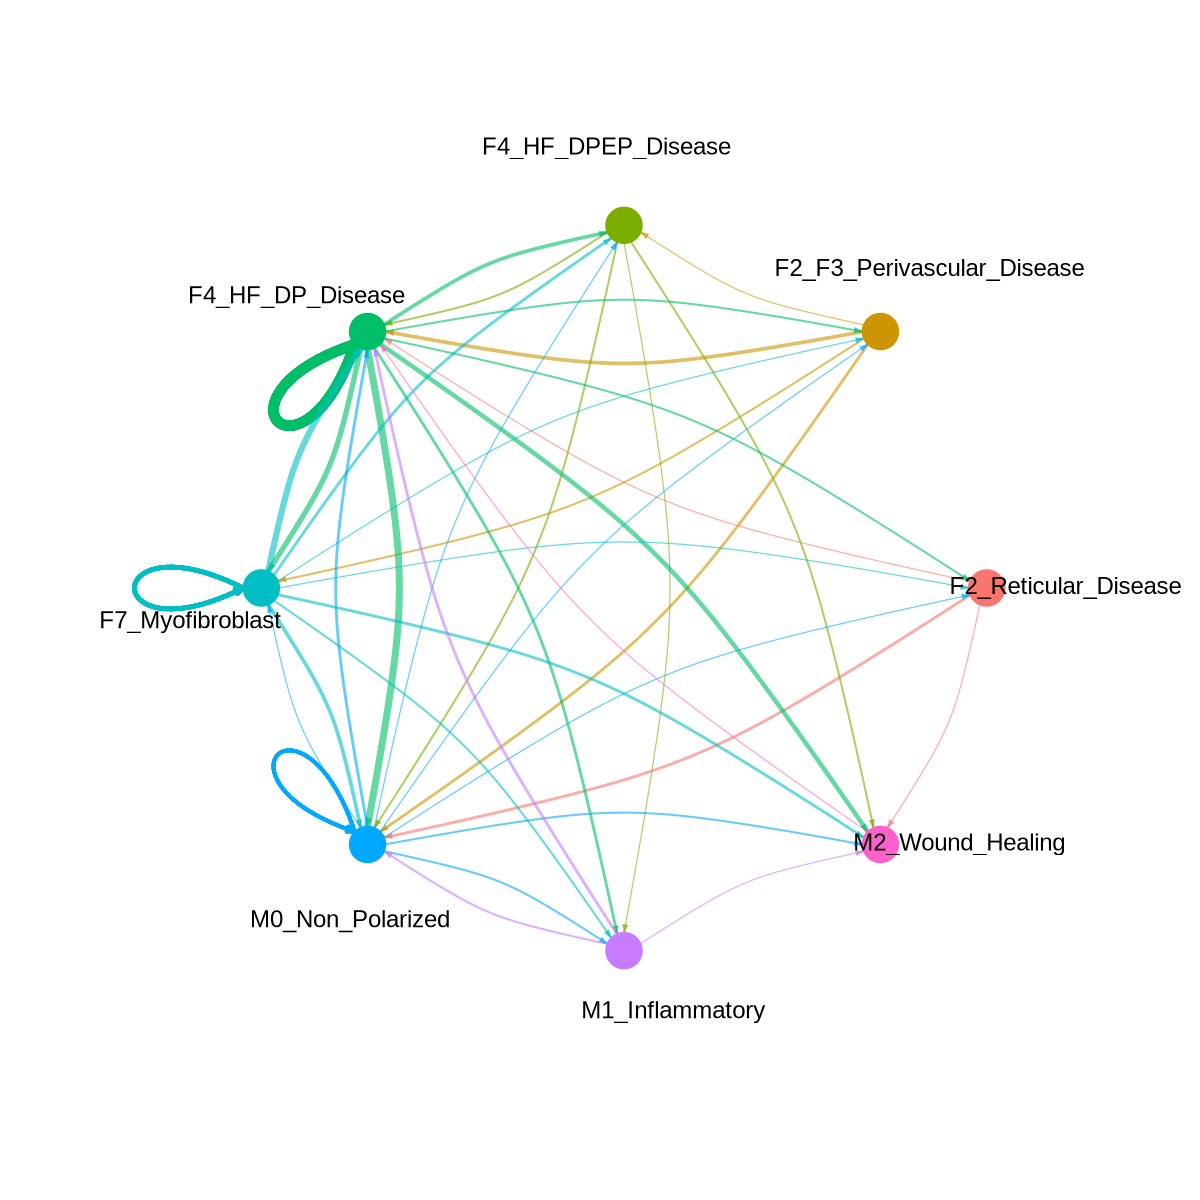

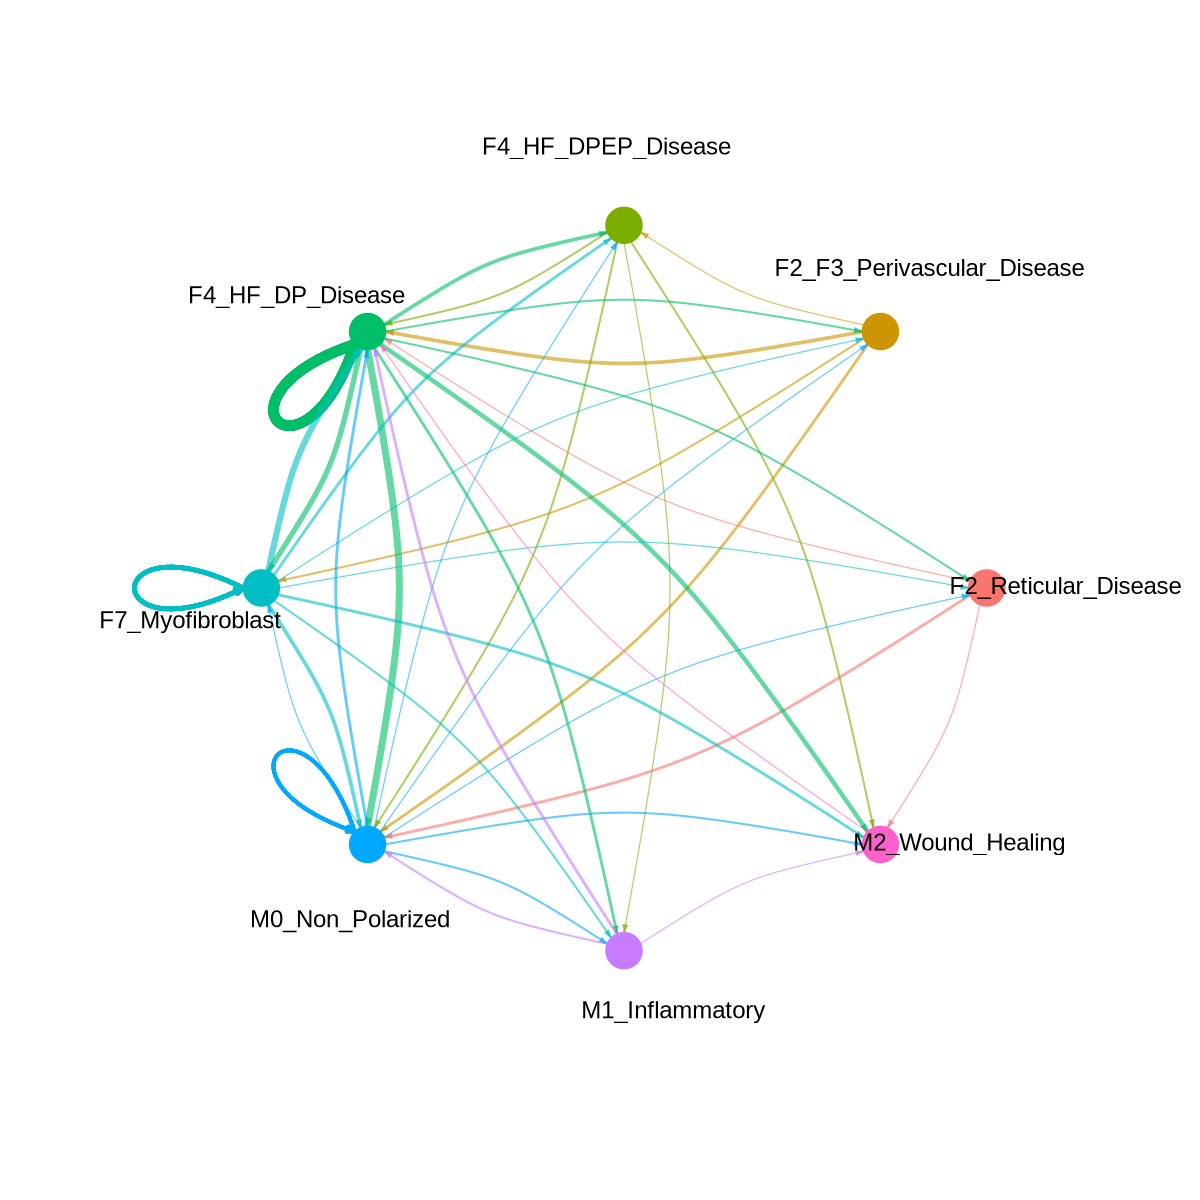

In [7]:
# 1. Force the Jupyter Notebook cell to draw a larger plot (10x10 inches)
options(repr.plot.width = 10, repr.plot.height = 10)

# 2. Define custom colors (Optional)
my_custom_colors <- setNames(scales::hue_pal()(length(disease_groups)), disease_groups)

# 3. Draw the plot directly
netVisual_circle(
  cellchat@net$count[disease_idx, disease_idx],
  weight.scale = TRUE,
  label.edge = FALSE,
  title.name = "Number of interactions (PMH disease groups only)",
  color.use = my_custom_colors,
  vertex.label.cex = 1.2,  # Adjust text size
  edge.width.max = 8,      # Adjust line thickness
  margin = 0.2             # Add padding around the circle
)

In [8]:
pathway.show <- "HA"

In [9]:
# Heatmap showing the communication network for a specific pathway
options(repr.plot.width = 8, repr.plot.height = 6)

netVisual_heatmap(
  cellchat, 
  signaling = pathway.show, 
  color.heatmap = "Reds",
  title.name = paste(pathway.show, "signaling network")
)

Do heatmap based on a single object 




ERROR: Error in slot(object, slot.name)$prob[, , signaling]: subscript out of bounds
